# Week 1 Internship Assignment
## Online Retail Data Cleaning, Preprocessing and Analysis

This notebook presents the data acquisition, cleaning, preprocessing, feature engineering and exploratory analysis performed on the UCI Online Retail Dataset using Python and Pandas.

## 1. Dataset Source and Description

The dataset used for this assignment is the Online Retail Dataset obtained from the UCI Machine Learning Repository. It contains transaction records from a UK-based online retail business.

The dataset includes information about invoices, products, quantities, prices, customers and countries. It was used to practice data cleaning, preprocessing, feature engineering and exploratory data analysis.

## 2. Data Acquisition

The Online Retail dataset was downloaded from the UCI Machine Learning Repository in Excel format. The file was uploaded to Google Colab and loaded into a Pandas DataFrame for further exploration and preprocessing.

## 3. Initial Data Exploration

Initial exploration was performed to understand the structure, size, columns, data types and statistical characteristics of the dataset.

The original dataset contained 541,909 rows and 8 columns. Pandas functions such as `head()`, `shape`, `columns`, `info()` and `describe()` were used for the initial inspection.

## 4. Missing Value Analysis

Missing values were checked to identify incomplete records in the dataset.

The original dataset contained 1,454 missing values in the Description column and 135,080 missing values in the CustomerID column. Rows with missing Description and CustomerID values were removed because these fields were required for the analysis.

## 5. Duplicate Analysis

Duplicate records were checked before preprocessing. A total of 5,268 duplicate rows were identified in the original dataset and removed.

After removing the duplicate records, no duplicate rows remained.

## 6. Data Cleaning and Validation

The dataset was cleaned by removing duplicate records, rows with missing Description and CustomerID values, cancelled transactions and records with non-positive UnitPrice values.

Invoice numbers beginning with "C" were treated as cancelled transactions. A total of 8,872 cancelled transactions were removed.

Quantity values were checked for negative values, and UnitPrice values were checked for values less than or equal to zero. A total of 40 records with non-positive UnitPrice values were removed.

Outliers in Quantity and UnitPrice were also examined using boxplots. Extreme values were not automatically removed because some may represent legitimate transactions.

## 7. Feature Engineering

Feature engineering was performed to create additional variables for analysis.

A new column named `TotalAmount` was created by multiplying Quantity by UnitPrice.

`TotalAmount = Quantity × UnitPrice`

The following date-related features were also extracted from InvoiceDate:
- Year
- Month
- Day
- Hour

After feature engineering, the dataset contained 13 columns.

## 8. Before vs After Cleaning

The dataset was reduced from 541,909 original records to 392,692 clean records after applying the required preprocessing steps.

The reduction in records was mainly due to the removal of duplicate, incomplete, cancelled and invalid records.

## 9. Final Dataset Verification

The final dataset was verified after completing all preprocessing steps.

The cleaned dataset contains 392,692 rows and 13 columns. All missing values and duplicate records were removed successfully.

The final dataset was also checked to confirm that the data types were appropriate for further analysis.

## 10. Exploratory Sales Analysis

After completing the data cleaning and preprocessing steps, basic sales analysis was performed to understand overall sales performance, country-wise sales, product-wise sales and monthly sales trends.

### 10.1 Overall Sales Metrics

Basic sales metrics were calculated using the cleaned dataset to understand total sales, average order value, total quantity sold and the number of unique transactions.

### 10.2 Country-wise Sales Analysis

Sales were grouped by country and sorted in descending order to identify the countries with the highest total sales. The analysis focused on the top 10 countries based on total sales.

### 10.3 Product-wise Sales Analysis

Product-level sales were analyzed by grouping the cleaned dataset by product description and calculating the total sales for each product. The analysis focused on the top 10 products based on total sales.

### 10.4 Monthly Sales Trend

Monthly sales were analyzed using the Year and Month features created during preprocessing. A line chart was used to visualize the sales trend over the available period.

## 11. Key Findings

- The original dataset contained 541,909 records.
- After preprocessing, 392,692 clean records remained.
- Missing values and duplicate records were removed.
- Cancelled transactions and non-positive UnitPrice records were excluded.
- Total sales were approximately 8.89 million.
- The United Kingdom recorded the highest total sales.
- Sales varied across products and months.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [6]:
df = pd.read_excel("Online Retail.xlsx")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

,0
CustomerID,24.926694
Description,0.268311
StockCode,0.000000
InvoiceNo,0.000000
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
Country,0.000000


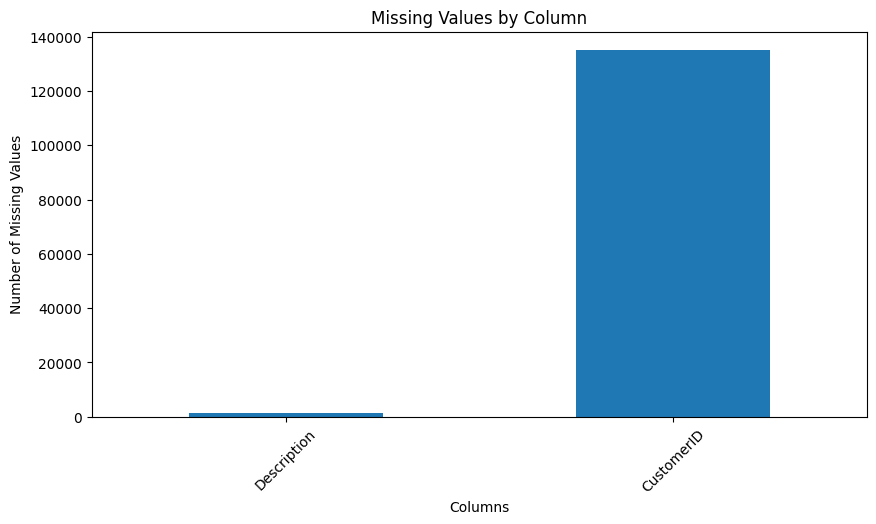

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
missing.plot(kind='bar')
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
df['Description'].isnull().sum()

np.int64(1454)

In [ ]:
df[df['Description'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


In [ ]:
df_clean = df.dropna(subset=['Description']).copy()

In [ ]:
df_clean['Description'].isnull().sum()

np.int64(0)

In [ ]:
df_clean['CustomerID'].isnull().sum()

np.int64(133583)

In [ ]:
df_clean = df_clean.dropna(subset=['CustomerID']).copy()

In [ ]:
df_clean['CustomerID'].isnull().sum()

np.int64(0)

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean = df_clean.drop_duplicates().copy()

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean['IsCancelled'] = df_clean['InvoiceNo'].astype(str).str.startswith('C')

In [ ]:
df_clean['IsCancelled'].value_counts()

,count
IsCancelled,
False,392732
True,8872


In [ ]:
df_clean[df_clean['IsCancelled'] == True].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,True


In [ ]:
df_clean = df_clean[df_clean['IsCancelled'] == False].copy()

In [ ]:
df_clean['IsCancelled'].value_counts()

,count
IsCancelled,
False,392732
True,8872


In [ ]:
df_clean = df_clean.drop(columns=['IsCancelled'])

In [ ]:
df_clean.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df_clean['Quantity'].describe()

,Quantity
count,392732.000000
mean,13.153718
std,181.588420
min,1.000000
25%,2.000000
50%,6.000000
75%,12.000000
max,80995.000000


In [ ]:
(df_clean['Quantity'] < 0).sum()

np.int64(0)

In [ ]:
df_clean['UnitPrice'].describe()

,UnitPrice
count,392732.000000
mean,3.125596
std,22.240725
min,0.000000
25%,1.250000
50%,1.950000
75%,3.750000
max,8142.750000


In [ ]:
(df_clean['UnitPrice'] <= 0).sum()

np.int64(40)

In [ ]:
df_clean = df_clean[df_clean['UnitPrice'] > 0].copy()

In [ ]:
(df_clean['UnitPrice'] <= 0).sum()

np.int64(0)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

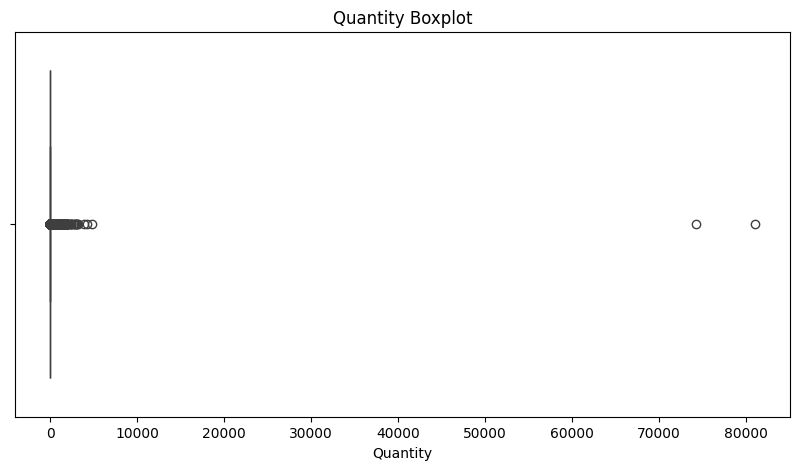

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['Quantity'])
plt.title('Quantity Boxplot')
plt.xlabel('Quantity')
plt.show()

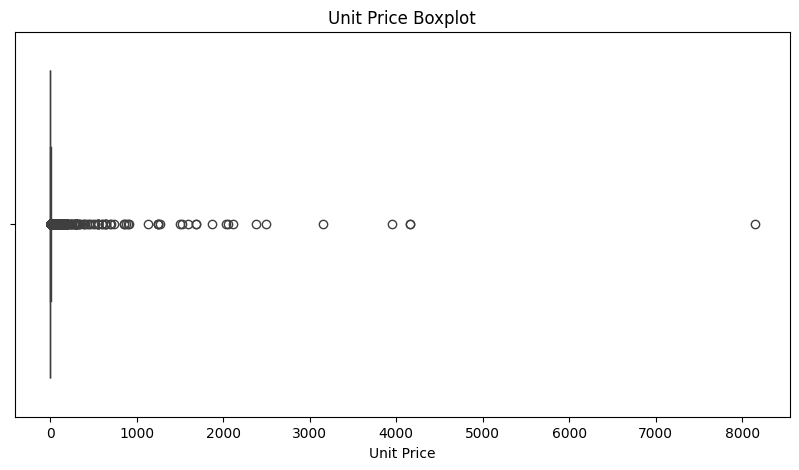

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['UnitPrice'])
plt.title('Unit Price Boxplot')
plt.xlabel('Unit Price')
plt.show()

In [ ]:
print("Quantity:")
print("Minimum:", df_clean['Quantity'].min())
print("Maximum:", df_clean['Quantity'].max())

print("\nUnitPrice:")
print("Minimum:", df_clean['UnitPrice'].min())
print("Maximum:", df_clean['UnitPrice'].max())

Quantity:
Minimum: 1
Maximum: 80995

UnitPrice:
Minimum: 0.001
Maximum: 8142.75


In [ ]:
print("Quantity <= 0:", (df_clean['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (df_clean['UnitPrice'] <= 0).sum())

Quantity <= 0: 0
UnitPrice <= 0: 0


In [ ]:
df_final = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0) &
    (~df_clean['InvoiceNo'].astype(str).str.startswith('C'))
].copy()

print("Rows after removing invalid and cancelled transactions:", len(df_final))

Rows after removing invalid and cancelled transactions: 392692


In [ ]:
print("Missing values:")
print(df_final.isnull().sum())

print("\nDuplicate rows:")
print(df_final.duplicated().sum())

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Duplicate rows:
0


In [ ]:
df_final['TotalAmount'] = df_final['Quantity'] * df_final['UnitPrice']

df_final[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
df_final['TotalAmount'].describe()

,TotalAmount
count,392692.000000
mean,22.631500
std,311.099224
min,0.001000
25%,4.950000
50%,12.450000
75%,19.800000
max,168469.600000


In [ ]:
df_final['Year'] = df_final['InvoiceDate'].dt.year
df_final['Month'] = df_final['InvoiceDate'].dt.month
df_final['Day'] = df_final['InvoiceDate'].dt.day
df_final['Hour'] = df_final['InvoiceDate'].dt.hour

df_final[['InvoiceDate', 'Year', 'Month', 'Day', 'Hour']].head()

,InvoiceDate,Year,Month,Day,Hour
0,2010-12-01 08:26:00,2010,12,1,8
1,2010-12-01 08:26:00,2010,12,1,8
2,2010-12-01 08:26:00,2010,12,1,8
3,2010-12-01 08:26:00,2010,12,1,8
4,2010-12-01 08:26:00,2010,12,1,8


In [ ]:
print("Final dataset shape:", df_final.shape)

Final dataset shape: (392692, 13)


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
 9   Year         392692 non-null  int32         
 10  Month        392692 non-null  int32         
 11  Day          392692 non-null  int32         
 12  Hour         392692 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(4), int64(1), object(4)
memory usage: 36.0+ MB


In [ ]:
df_final.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalAmount,0
Year,0


In [ ]:
df_final.duplicated().sum()

np.int64(0)

In [ ]:
df_final.to_csv("Online_Retail_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
 9   Year         392692 non-null  int32         
 10  Month        392692 non-null  int32         
 11  Day          392692 non-null  int32         
 12  Hour         392692 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(4), int64(1), object(4)
memory usage: 36.0+ MB


In [ ]:
df_final.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,8


In [ ]:
print("Final dataset shape:", df_final.shape)

Final dataset shape: (392692, 13)


In [ ]:
print(df_final.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'Year', 'Month', 'Day', 'Hour']


In [ ]:
print("Total Sales:", df_final['TotalAmount'].sum())
print("Average Order Value:", df_final['TotalAmount'].mean())
print("Total Quantity Sold:", df_final['Quantity'].sum())
print("Number of Transactions:", df_final['InvoiceNo'].nunique())

Total Sales: 8887208.894
Average Order Value: 22.6314997351614
Total Quantity Sold: 5152002
Number of Transactions: 18532


In [ ]:
country_sales = df_final.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)

country_sales.head(10)

,TotalAmount
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [ ]:
product_sales = df_final.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False)

product_sales.head(10)

,TotalAmount
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


In [ ]:
monthly_sales = df_final.groupby(['Year', 'Month'])['TotalAmount'].sum()

monthly_sales

Year  Month
2010  12        570422.730
2011  1         568101.310
      2         446084.920
      3         594081.760
      4         468374.331
      5         677355.150
      6         660046.050
      7         598962.901
      8         644051.040
      9         950690.202
      10       1035642.450
      11       1156205.610
      12        517190.440
Name: TotalAmount, dtype: float64

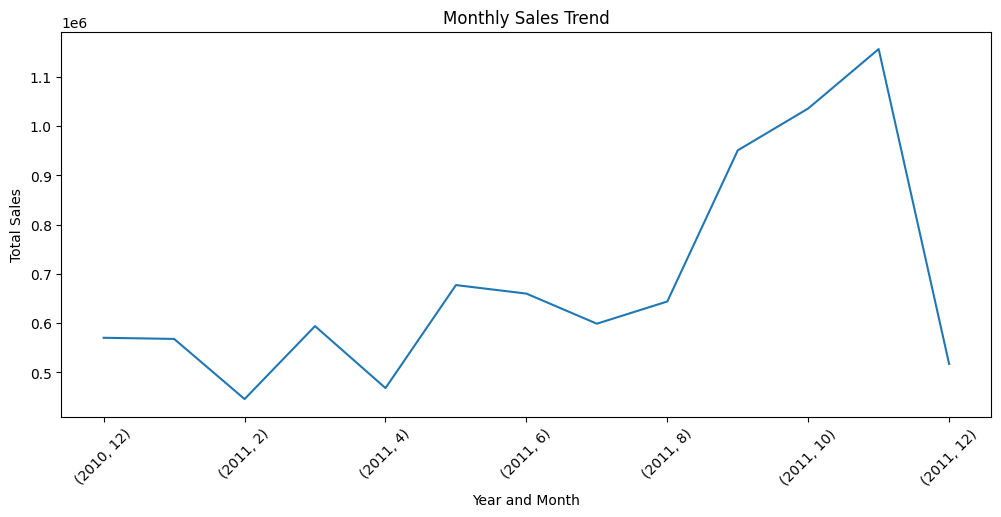

In [ ]:
monthly_sales.plot(kind='line', figsize=(12, 5))

plt.title('Monthly Sales Trend')
plt.xlabel('Year and Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_final.to_csv('Online_Retail_Cleaned.csv', index=False)

print("Final cleaned dataset saved successfully.")

Final cleaned dataset saved successfully.


In [ ]:
from google.colab import files

files.download('Online_Retail_Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("Total Sales:", df_final['TotalAmount'].sum())
print("Average Order Value:", df_final['TotalAmount'].mean())
print("Total Quantity Sold:", df_final['Quantity'].sum())
print("Number of Transactions:", df_final['InvoiceNo'].nunique())

Total Sales: 8887208.894
Average Order Value: 22.6314997351614
Total Quantity Sold: 5152002
Number of Transactions: 18532


In [ ]:
country_sales = df_final.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)

country_sales.head(10)

,TotalAmount
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [ ]:
comparison = pd.DataFrame({
    'Stage': [
        'Original dataset',
        'After removing duplicates',
        'After removing missing Description/CustomerID',
        'After removing cancellations',
        'After removing non-positive UnitPrice',
        'Final cleaned dataset'
    ],
    'Rows': [
        541909,
        536641,
        401604,
        392732,
        392692,
        392692
    ]
})

comparison

,Stage,Rows
0,Original dataset,541909
1,After removing duplicates,536641
2,After removing missing Description/CustomerID,401604
3,After removing cancellations,392732
4,After removing non-positive UnitPrice,392692
5,Final cleaned dataset,392692


In [ ]:
print("Final dataset shape:", df_final.shape)

print("\nMissing values:")
print(df_final.isnull().sum())

print("\nDuplicate rows:")
print(df_final.duplicated().sum())

print("\nData types:")
print(df_final.dtypes)

Final dataset shape: (392692, 13)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
Year           0
Month          0
Day            0
Hour           0
dtype: int64

Duplicate rows:
0

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalAmount           float64
Year                    int32
Month                   int32
Day                     int32
Hour                    int32
dtype: object


## Conclusion

The Online Retail dataset was successfully explored, cleaned and preprocessed using Python and Pandas. Duplicate records, missing values, cancelled transactions and invalid price values were handled during the cleaning process.

After preprocessing, the final dataset contained 392,692 records and 13 columns with no missing values or duplicate rows. Additional features such as TotalAmount, Year, Month, Day and Hour were created for further analysis.

The cleaned dataset was then used to analyze overall sales, country-wise sales, product-wise sales and monthly sales trends. This assignment provided practical experience in data cleaning, preprocessing, feature engineering and exploratory data analysis.